# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

## Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

## 1. Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [1]:
# ── Library Imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [2]:
df_raw = pd.read_csv('data/vehicles.csv')
print(f'Dataset shape: {df_raw.shape}')
df_raw.head(10)

Dataset shape: (426880, 18)


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
5,7222379453,hudson valley,1600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
6,7221952215,hudson valley,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
7,7220195662,hudson valley,15995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
8,7209064557,medford-ashland,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,or
9,7219485069,erie,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pa


In [3]:
df_raw.tail(10)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
426870,7301592119,wyoming,22990,2020.0,hyundai,sonata se sedan 4d,good,NaN,gas,3066.0,clean,other,5NPEG4JAXLH051710,fwd,NaN,sedan,blue,wy
426871,7301591639,wyoming,17990,2018.0,kia,sportage lx sport utility 4d,good,NaN,gas,34239.0,clean,other,KNDPMCAC7J7417329,NaN,NaN,SUV,NaN,wy
426872,7301591201,wyoming,32590,2020.0,mercedes-benz,c-class c 300,good,NaN,gas,19059.0,clean,other,55SWF8DB6LU325050,rwd,NaN,sedan,white,wy
426873,7301591202,wyoming,30990,2018.0,mercedes-benz,glc 300 sport,good,NaN,gas,15080.0,clean,automatic,WDC0G4JB6JV019749,rwd,NaN,other,white,wy
426874,7301591199,wyoming,33590,2018.0,lexus,gs 350 sedan 4d,good,6 cylinders,gas,30814.0,clean,automatic,JTHBZ1BLXJA012999,rwd,NaN,sedan,white,wy
426875,7301591192,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,wy
426876,7301591187,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,wy
426877,7301591147,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,wy
426878,7301591140,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,wy
426879,7301591129,wyoming,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,gas,22716.0,clean,other,WBA4J1C58KBM14708,rwd,NaN,coupe,NaN,wy


In [4]:
empty_vals = df_raw.isnull().sum().sort_values(ascending=False)
pd.DataFrame({'Empty Count': empty_vals})

,Empty Count
size,306361
cylinders,177678
condition,174104
VIN,161042
drive,130567
paint_color,130203
type,92858
manufacturer,17646
title_status,8242
model,5277


In [5]:
df_raw[['price', 'year', 'odometer']].describe().round(1)

,price,year,odometer
count,4.268800e+05,425675.0,422480.0
mean,7.519900e+04,2011.2,98043.3
std,1.218228e+07,9.5,213881.5
min,0.000000e+00,1900.0,0.0
25%,5.900000e+03,2008.0,37704.0
50%,1.395000e+04,2013.0,85548.0
75%,2.648580e+04,2017.0,133542.5
max,3.736929e+09,2022.0,10000000.0


**Observations**
- 426,880 rows.
- 18 columns.
- There are missing columns in several lines of data.
- There are outliers in age (very old) and price (very expensive).

## 2. Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [6]:
# Dropping id, VIN and region
df = df_raw.drop(columns=['id', 'VIN', 'region'])

# 500 <= price <= 200_000
df = df[(df['price'] >= 500) & (df['price'] <= 200_000)]

# 1980 <= year <= 2022
df = df[(df['year'] >= 1980) & (df['year'] <= 2022)]

# odometer <= 500_000
df = df[df['odometer'] <= 500_000]

# using 2022 to determine the afe as this is the max year in the dataset.
df['age'] = 2022 - df['year']

# log transformation/normalization of price
df['log_price'] = np.log1p(df['price'])

print(f'Dataset after cleaning: {df.shape}')
print(f'Rows removed:           {len(df_raw) - len(df):,}')
df[['price', 'log_price', 'age', 'odometer']].describe().round(1)

Dataset after cleaning: (372571, 17)
Rows removed:           54,309


,price,log_price,age,odometer
count,372571.0,372571.0,372571.0,372571.0
mean,19262.9,9.5,10.0,93834.1
std,14839.9,0.9,6.4,64254.0
min,500.0,6.2,0.0,0.0
25%,7800.0,9.0,5.0,39038.5
50%,15937.0,9.7,9.0,88790.0
75%,27990.0,10.2,14.0,136860.0
max,200000.0,12.2,42.0,500000.0


In [7]:
print(f"Median sale price: ${df['price'].median():,.0f}")

Median sale price: $15,937


In [8]:
print(f"Median age: {df['age'].median():,.0f}")

Median age: 9


In [9]:
print(f"Median odometer: {df['odometer'].median():,.0f}")

Median odometer: 88,790


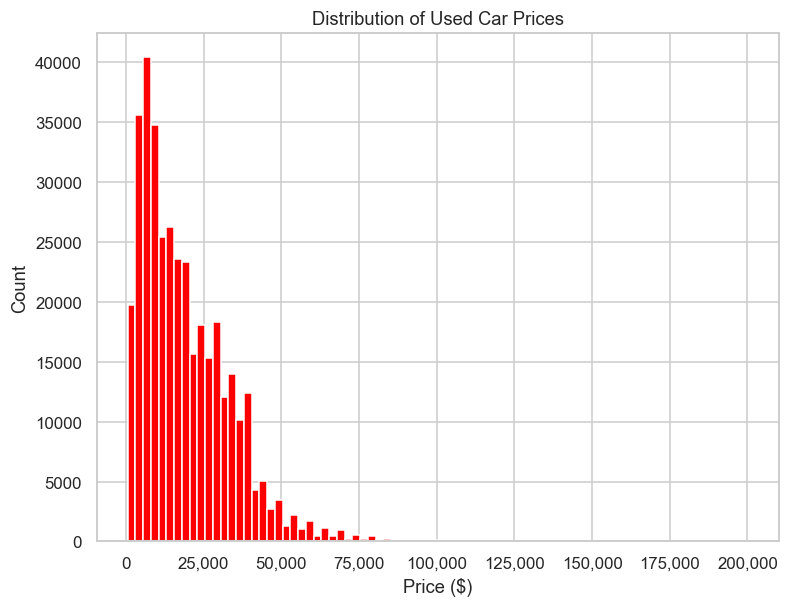

In [10]:
fig,ax = plt.subplots(figsize=(8, 6))
ax.hist(df['price'], bins=80, color='red')
ax.set_title('Distribution of Used Car Prices')
ax.set_xlabel('Price ($)')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

Text(0, 0.5, 'Count')

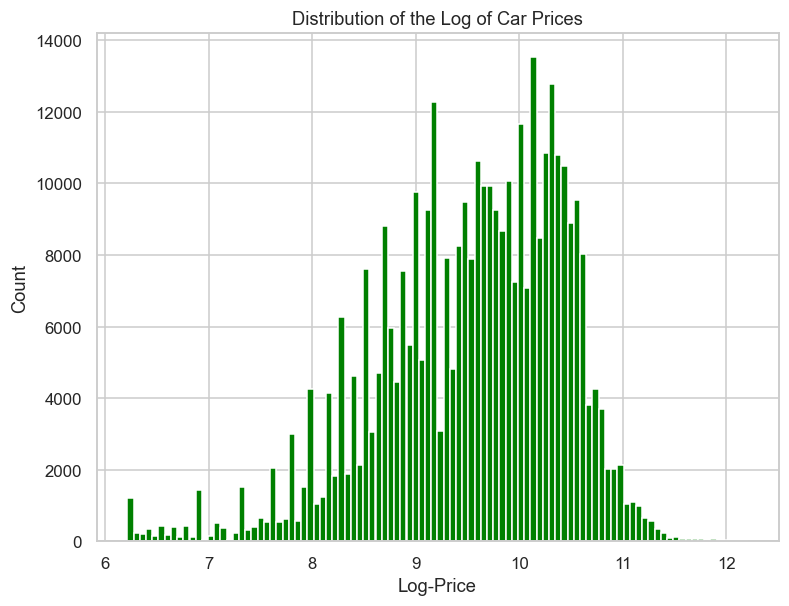

In [11]:
fig,ax = plt.subplots(figsize=(8, 6))
ax.hist(df['log_price'], bins=100, color='green')
ax.set_title('Distribution of the Log of Car Prices')
ax.set_xlabel('Log-Price')
ax.set_ylabel('Count')

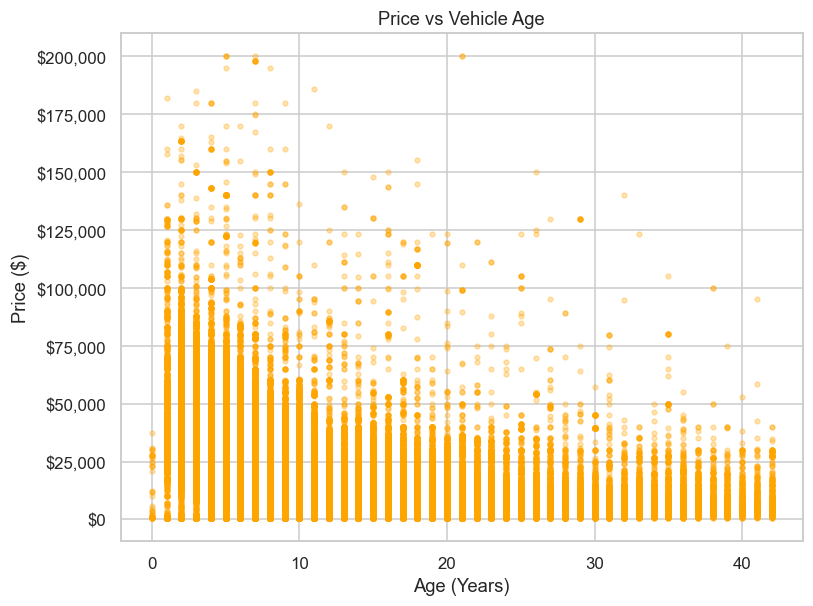

In [12]:
fig,ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['age'], df['price'], alpha=0.3, s=10, color='orange')
ax.set_title('Price vs Vehicle Age')
ax.set_xlabel('Age (Years)')
ax.set_ylabel('Price ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

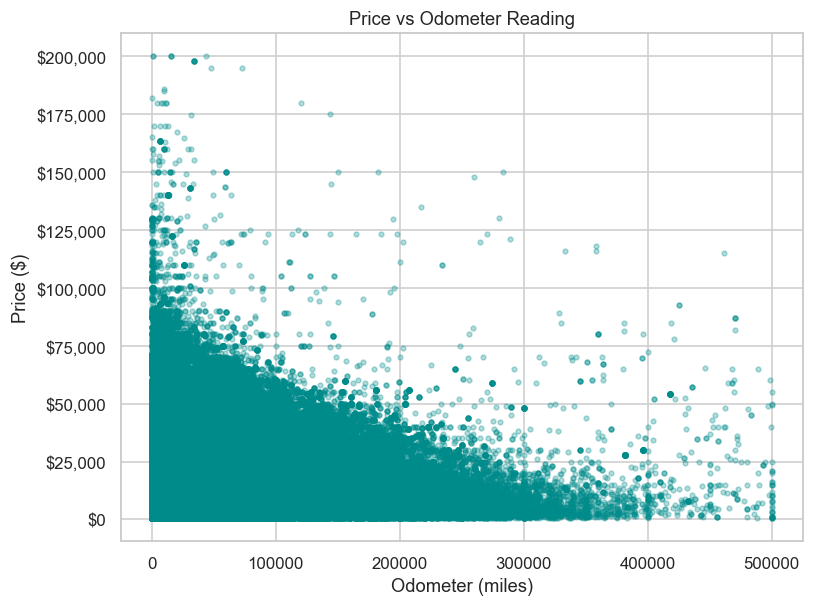

In [13]:
fig,ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['odometer'], df['price'], alpha=0.3, s=10, color='darkcyan')
ax.set_title('Price vs Odometer Reading')
ax.set_xlabel('Odometer (miles)')
ax.set_ylabel('Price ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

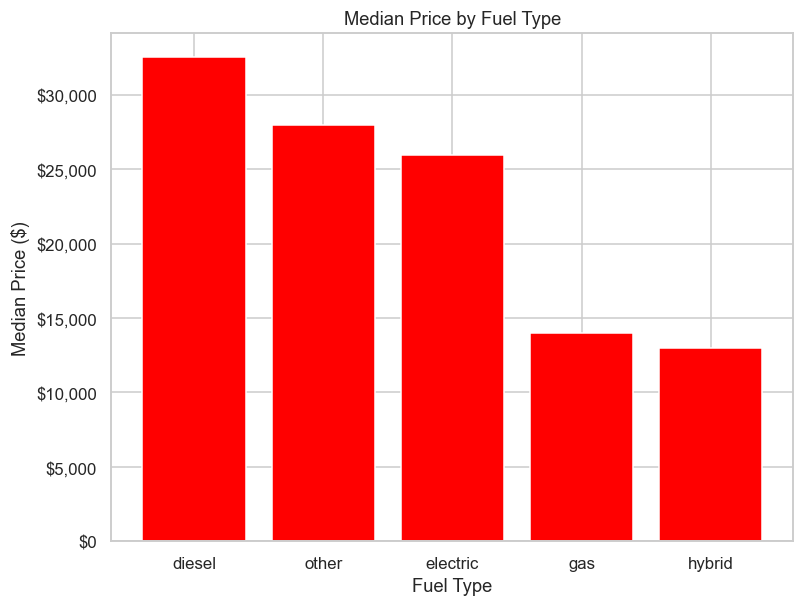

In [14]:
fig,ax = plt.subplots(figsize=(8, 6))
fuel_med = (df[df['fuel'].notna()].groupby('fuel')['price'].median().sort_values(ascending=False))
ax.bar(fuel_med.index, fuel_med.values, color='red')
ax.set_title('Median Price by Fuel Type')
ax.set_xlabel('Fuel Type')
ax.set_ylabel('Median Price ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

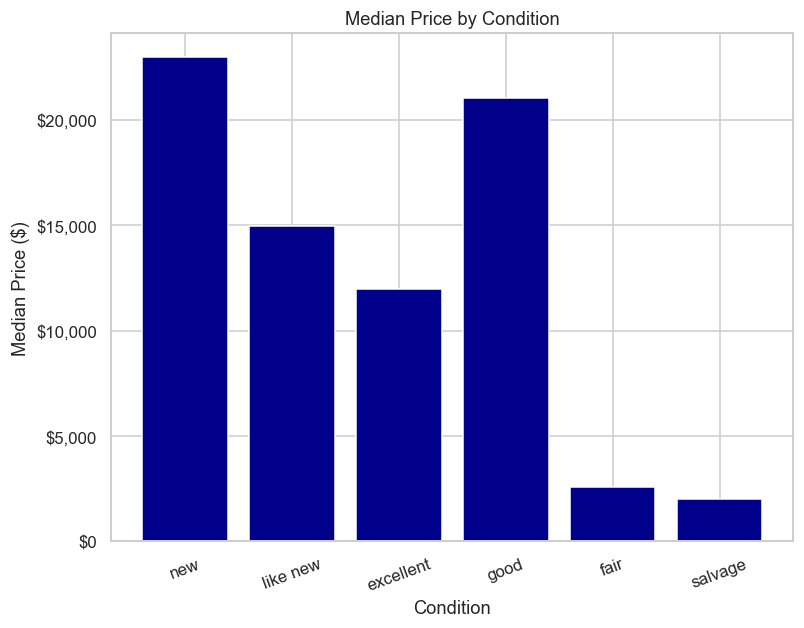

In [15]:
fig,ax = plt.subplots(figsize=(8, 6))
condition = ['new', 'like new', 'excellent', 'good', 'fair', 'salvage']
cond_med = (df[df['condition'].notna()].groupby('condition')['price'].median().reindex(condition).dropna())
ax.bar(cond_med.index, cond_med.values, color='darkblue')
ax.set_title('Median Price by Condition')
ax.set_xlabel('Condition')
ax.set_ylabel('Median Price ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.tick_params(axis='x', rotation=20)

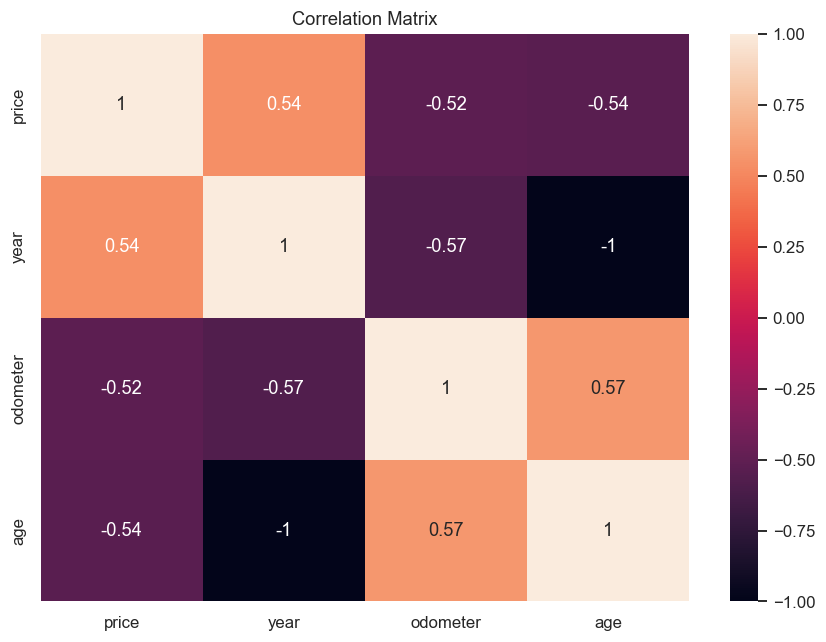

In [16]:
corr = df[['price', 'year', 'odometer', 'age']].corr()
fig,ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Summary
- Dropped id, VIN and region
- Kept only prices between \\$500 and \\$150K, years between 1980 and 2022 and odometer ≤ 500,000 miles.

## 3. Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

### 3.1. OLS Linear Regression

In [17]:
features = ['age', 'odometer', 'condition', 'fuel', 'title_status','transmission', 'drive', 'type', 'cylinders', 'manufacturer']
target   = 'log_price'

model_df = df[features + [target]].dropna(subset=['age', 'odometer'])
#print(f'Modeling dataset: {model_df.shape}')

num_feats = ['age', 'odometer']
cat_feats = ['condition', 'fuel', 'title_status', 'transmission','drive', 'type', 'cylinders', 'manufacturer']

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())          # required for Ridge/Lasso
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_feats),
    ('cat', cat_pipe, cat_feats)
])

X = model_df[features]
y = model_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

In [18]:
# Baseline model; minimises L2 loss (sum of squared residuals)
# Cross-validation uses neg_mean_absolute_error (MAE) as the scoring metric

lr_pipe = Pipeline([('pre', preprocessor), ('model', LinearRegression())])

lr_cv_mae = cross_val_score(lr_pipe, X_train, y_train,
                            cv=5, scoring='neg_mean_absolute_error')
print(f'OLS  CV MAE (log, 5-fold): {-lr_cv_mae.mean():.4f} ± {lr_cv_mae.std():.4f}')

lr_pipe.fit(X_train, y_train)
lr_pred      = lr_pipe.predict(X_test)
lr_mae_log   = mean_absolute_error(y_test, lr_pred)
lr_mae_dollar = mean_absolute_error(np.expm1(y_test), np.expm1(lr_pred))
print(f'OLS  Test MAE (log):       {lr_mae_log:.4f}')
print(f'OLS  Test MAE ($):         ${lr_mae_dollar:,.0f}')

OLS  CV MAE (log, 5-fold): 0.4341 ± 0.0016
OLS  Test MAE (log):       0.4313
OLS  Test MAE ($):         $6,856


### 3.2. Ridge Regression

Ridge  Best alpha:     0.01
Ridge  Best CV MAE:    0.4341
Ridge  Test MAE (log): 0.4313
Ridge  Test MAE ($):   $6,856


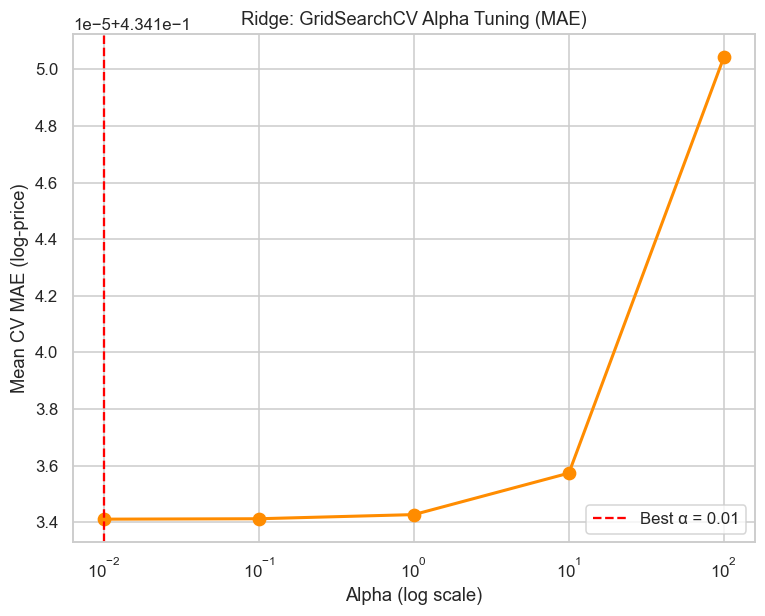

In [19]:
ridge_pipe   = Pipeline([('pre', preprocessor), ('model', Ridge())])
ridge_params = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_gs = GridSearchCV(ridge_pipe, ridge_params,
                        cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
ridge_gs.fit(X_train, y_train)

print(f'Ridge  Best alpha:     {ridge_gs.best_params_["model__alpha"]}')
print(f'Ridge  Best CV MAE:    {-ridge_gs.best_score_:.4f}')

ridge_pred       = ridge_gs.predict(X_test)
ridge_mae_log    = mean_absolute_error(y_test, ridge_pred)
ridge_mae_dollar = mean_absolute_error(np.expm1(y_test), np.expm1(ridge_pred))
print(f'Ridge  Test MAE (log): {ridge_mae_log:.4f}')
print(f'Ridge  Test MAE ($):   ${ridge_mae_dollar:,.0f}')

ridge_gs_df = pd.DataFrame(ridge_gs.cv_results_)
ridge_gs_df[['param_model__alpha', 'mean_test_score', 'std_test_score']].round(6)

fig,ax = plt.subplots(figsize=(8, 6))

r_alphas = ridge_gs_df['param_model__alpha'].astype(float)
r_scores = -ridge_gs_df['mean_test_score']   # flip sign: lower MAE is better

ax.semilogx(r_alphas, r_scores, 'o-', color='darkorange', linewidth=2, markersize=8)
ax.axvline(ridge_gs.best_params_['model__alpha'], color='red', linestyle='--',
                label=f"Best α = {ridge_gs.best_params_['model__alpha']}")
ax.set_title('Ridge: GridSearchCV Alpha Tuning (MAE)')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Mean CV MAE (log-price)')
ax.legend()

### 3.3. Lasso Regression

Lasso  Best alpha:     0.0001
Lasso  Best CV MAE:    0.4341
Lasso  Test MAE (log): 0.4314
Lasso  Test MAE ($):   $6,856


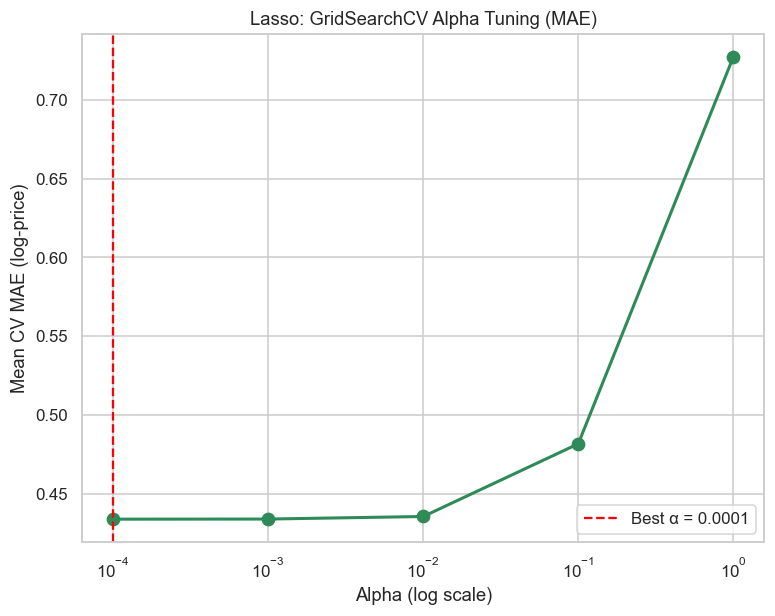

In [20]:
lasso_pipe   = Pipeline([('pre', preprocessor), ('model', Lasso(max_iter=5000))])
lasso_params = {'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}

lasso_gs = GridSearchCV(lasso_pipe, lasso_params,
                        cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
lasso_gs.fit(X_train, y_train)

print(f'Lasso  Best alpha:     {lasso_gs.best_params_["model__alpha"]}')
print(f'Lasso  Best CV MAE:    {-lasso_gs.best_score_:.4f}')

lasso_pred       = lasso_gs.predict(X_test)
lasso_mae_log    = mean_absolute_error(y_test, lasso_pred)
lasso_mae_dollar = mean_absolute_error(np.expm1(y_test), np.expm1(lasso_pred))
print(f'Lasso  Test MAE (log): {lasso_mae_log:.4f}')
print(f'Lasso  Test MAE ($):   ${lasso_mae_dollar:,.0f}')

lasso_gs_df = pd.DataFrame(lasso_gs.cv_results_)
lasso_gs_df[['param_model__alpha', 'mean_test_score', 'std_test_score']].round(6)

l_alphas = lasso_gs_df['param_model__alpha'].astype(float)
l_scores = -lasso_gs_df['mean_test_score']

fig,ax = plt.subplots(figsize=(8, 6))

ax.semilogx(l_alphas, l_scores, 'o-', color='seagreen', linewidth=2, markersize=8)
ax.axvline(lasso_gs.best_params_['model__alpha'], color='red', linestyle='--',
                label=f"Best α = {lasso_gs.best_params_['model__alpha']}")
ax.set_title('Lasso: GridSearchCV Alpha Tuning (MAE)')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Mean CV MAE (log-price)')
ax.legend()

## 4. Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [21]:
summary = pd.DataFrame({
    'Model':          ['OLS Linear Regression', 'Ridge (GridSearchCV)', 'Lasso (GridSearchCV)'],
    'Best Alpha':     ['N/A',
                       str(ridge_gs.best_params_['model__alpha']),
                       str(lasso_gs.best_params_['model__alpha'])],
    'CV MAE (log)':   [f'{-lr_cv_mae.mean():.4f} ± {lr_cv_mae.std():.4f}',
                       f'{-ridge_gs.best_score_:.4f}',
                       f'{-lasso_gs.best_score_:.4f}'],
    'Test MAE (log)': [f'{lr_mae_log:.4f}', f'{ridge_mae_log:.4f}', f'{lasso_mae_log:.4f}'],
    'Test MAE ($)':   [f'${lr_mae_dollar:,.0f}', f'${ridge_mae_dollar:,.0f}', f'${lasso_mae_dollar:,.0f}']
})
summary

,Model,Best Alpha,CV MAE (log),Test MAE (log),Test MAE ($)
0,OLS Linear Regression,N/A,0.4341 ± 0.0016,0.4313,"$6,856"
1,Ridge (GridSearchCV),0.01,0.4341,0.4313,"$6,856"
2,Lasso (GridSearchCV),0.0001,0.4341,0.4314,"$6,856"


In [22]:
feat_names_out = num_feats + cat_feats

best_lasso_pipe = Pipeline([
    ('pre',   preprocessor),
    ('model', Lasso(alpha=lasso_gs.best_params_['model__alpha'], max_iter=5000))
])
best_lasso_pipe.fit(X_train, y_train)

lasso_coefs = pd.Series(
    best_lasso_pipe.named_steps['model'].coef_,
    index=feat_names_out
).sort_values(key=abs, ascending=False)

print('Lasso coefficients (sorted by abs magnitude):')
print(lasso_coefs.to_string())

Lasso coefficients (sorted by abs magnitude):
age            -0.388917
odometer       -0.270852
cylinders       0.205008
fuel           -0.179665
transmission    0.089125
title_status   -0.087442
drive          -0.034344
condition      -0.007541
type           -0.004591
manufacturer   -0.000213


## 5. Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

Based on this data, the median car price is \$15,937, their median age is 8 years and the median odometer reading is 88,790 miles.

According to the Lasso analysis, the two most important factors determining the price of a vehicle are its age and odometer reading, which have negative correlation with the asked price, while number of cylinders and fuel efficiency are positively correlated with the asked price. Beyond these 4 factors, other aspects of used vehicles such as the type of transmission, its condition and manufacturer are not as relevant to determine the final price.